In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [65]:
data = fetch_california_housing()

x = data.data
y = data.target
x = (x - np.mean(x, axis=0)) / np.std(x, axis=0)

In [66]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [67]:
print("Training features shape:", x_train.shape)
print("Testing features shape:", x_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (16512, 8)
Testing features shape: (4128, 8)
Training target shape: (16512,)
Testing target shape: (4128,)


In [68]:
m = x_train.shape[0]
x_train = np.c_[np.ones(m), x_train]
x_test = np.c_[np.ones(x_test.shape[0]), x_test]

In [69]:
n= x_train.shape[1]
w=np.zeros(n)

In [70]:
def compute_mse(x,y,w):
    h = x.dot(w)
    error = h-y
    mse = 1/m*np.sum(error**2)
    return mse

In [71]:
def bgd(x, y, alpha, itr):
    m = len(y)
    n = x.shape[1]
    w = np.zeros(n)
    cost_history = []

    for i in range(itr):
        h = x.dot(w)
        error = h - y
        gradient = (2/m) * x.T.dot(error)
        w = w - alpha * gradient

        cost = (1/m) * np.sum(error**2)
        cost_history.append(cost)

    return w, cost_history

In [72]:
alphas = [0.0001, 0.001, 0.01]
itr = 10000

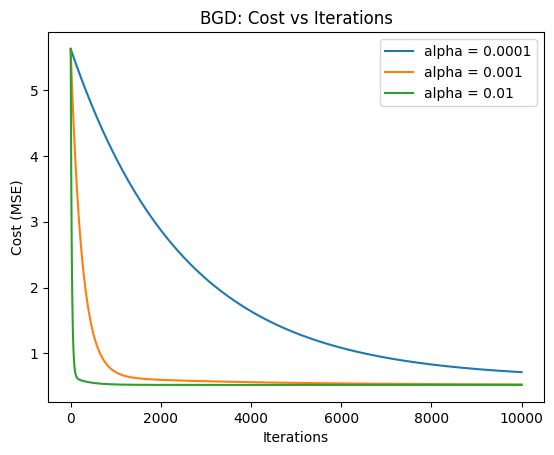

In [73]:
for alpha in alphas:
    w, cost_history = bgd(x_train, y_train, alpha, itr)
    plt.plot(cost_history, label = f"alpha = {alpha}")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("BGD: Cost vs Iterations")
plt.legend()
plt.show()

In [74]:
def sgd(x, y, alpha, epochs):
    m = len(y)
    n = x.shape[1]
    w = np.zeros(n)
    cost_history = []

    for epoch in range(epochs):
        for i in range(m):
            xi = x[i]
            yi = y[i]

            error = xi.dot(w) - yi
            gradient = (2) * (error * xi)
            w = w - alpha * gradient

        cost = (1/m) * np.sum((x.dot(w) - y)**2)
        cost_history.append(cost)

    return w, cost_history




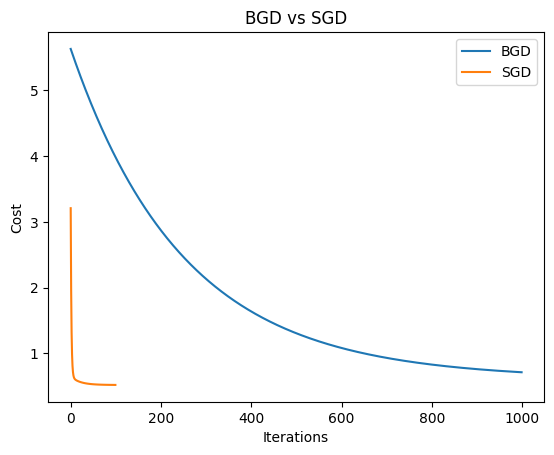

Test MSE: 0.1797274997974666


In [75]:
W_bgd, cost_bgd = bgd(x_train, y_train, 0.001, 1000)
W_sgd, cost_sgd = sgd(x_train, y_train, 0.00001, 100)
plt.plot(cost_bgd, label="BGD")
plt.plot(cost_sgd, label="SGD")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.title("BGD vs SGD")
plt.show()
test_mse = compute_mse(x_test, y_test, W_bgd)
print("Test MSE:", test_mse)